/Users/marcussmith/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  4 of 4 completed


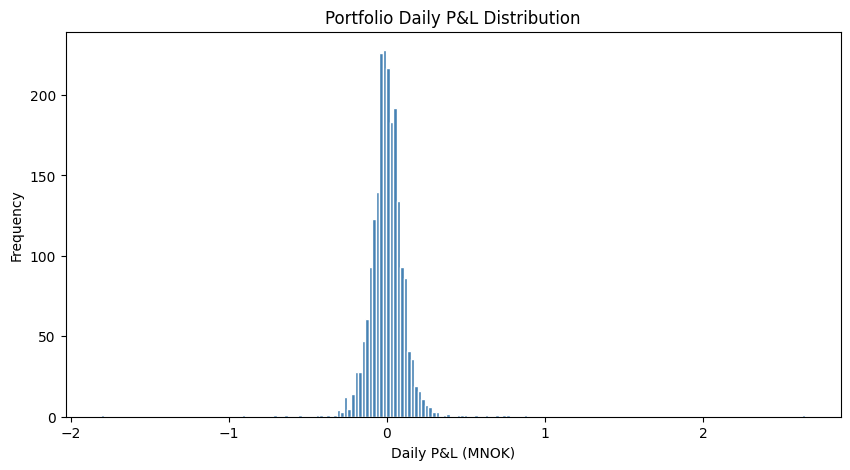

In [1]:
"""
Market Risk Analyst Project
"""

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tickers = {
    "EURNOK": "EURNOK=X",
    "USDNOK": "USDNOK=X",
    "GBPNOK": "GBPNOK=X",
    "EURUSD": "EURUSD=X",
}

prices = yf.download(list(tickers.values()), period="8y", auto_adjust=True)["Close"]
prices = prices.rename(columns={v: k for k, v in tickers.items()})
prices = prices.dropna()

prices.head()

log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()

positions = {
    "EURNOK": 10_000_000,
    "USDNOK":  5_000_000,
    "GBPNOK":  3_000_000,
    "EURUSD":  2_000_000,
}

pnl = sum(log_returns[pair] * notional for pair, notional in positions.items())
pnl.name = "Portfolio P&L (NOK)"

pnl.head()

plt.figure(figsize=(10, 5))
plt.hist(pnl / 1_000_000, bins=200, color="steelblue", edgecolor="white")
plt.xlabel("Daily P&L (MNOK)")
plt.ylabel("Frequency")
plt.title("Portfolio Daily P&L Distribution")
plt.show()

Historical VaR (99%, 1-day):      172,498 NOK
Parametric VaR (99%, 1-day):      184,396 NOK
Number of exceptions: 21
Basel zone: RED


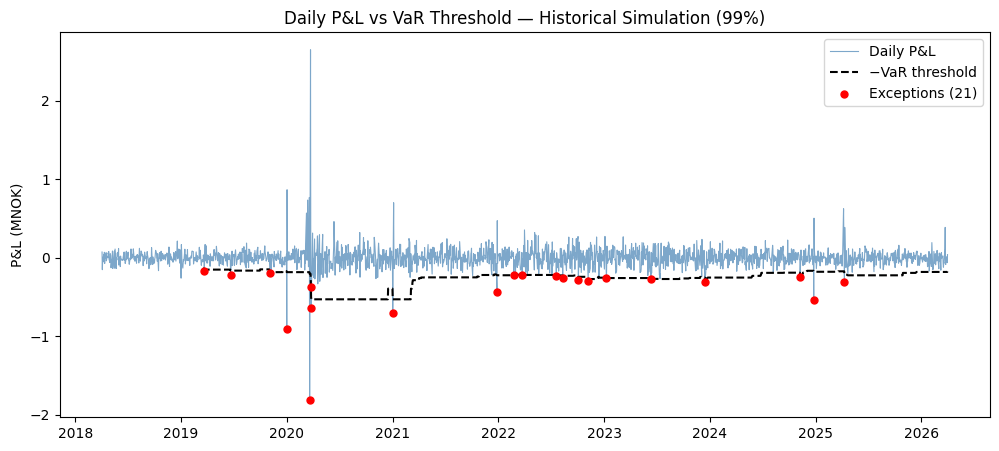

In [2]:
confidence = 0.99
window = 250

# Historical Simulation VaR
# Take the 1st percentile of the trailing 250-day P&L window
hist_var = -pnl.rolling(window).quantile(1 - confidence)

# Parametric VaR
# Assumes normally distributed returns: VaR = -(mu - z*sigma)
z = 2.326  # 99% confidence z-score
param_var = -(pnl.rolling(window).mean() - z * pnl.rolling(window).std())

# Print today's VaR estimate
print(f"Historical VaR (99%, 1-day): {hist_var.iloc[-1]:>12,.0f} NOK")
print(f"Parametric VaR (99%, 1-day): {param_var.iloc[-1]:>12,.0f} NOK")

# Align series and find exception days (actual loss exceeded VaR estimate)
aligned_pnl, aligned_var = pnl.align(hist_var, join="inner")
exceptions = aligned_pnl < -aligned_var
n_exceptions = exceptions.sum()

print(f"Number of exceptions: {n_exceptions}")

# Basel traffic light
if n_exceptions <= 4:
    zone = "GREEN"
elif n_exceptions <= 9:
    zone = "YELLOW"
else:
    zone = "RED"

print(f"Basel zone: {zone}")

fig, ax = plt.subplots(figsize=(12, 5))

# Plot daily P&L
ax.plot(aligned_pnl.index, aligned_pnl / 1_000_000, 
        color="steelblue", linewidth=0.8, alpha=0.7, label="Daily P&L")

# Plot negative VaR as the loss threshold line
ax.plot(aligned_var.index, -aligned_var / 1_000_000, 
        color="black", linewidth=1.5, linestyle="--", label="−VaR threshold")

# Mark exception days as red dots
ax.scatter(aligned_pnl.index[exceptions], 
           aligned_pnl[exceptions] / 1_000_000,
           color="red", s=25, zorder=5, label=f"Exceptions ({n_exceptions})")

ax.set_ylabel("P&L (MNOK)")
ax.set_title("Daily P&L vs VaR Threshold — Historical Simulation (99%)")
ax.legend()
plt.show()

NOK -10% depreciation:       1,715,583 NOK
USD +8% strength:              597,907 NOK
COVID crash total P&L:       2,397,106 NOK
Worst single day:           -1,808,234 NOK
Duration:              32 trading days


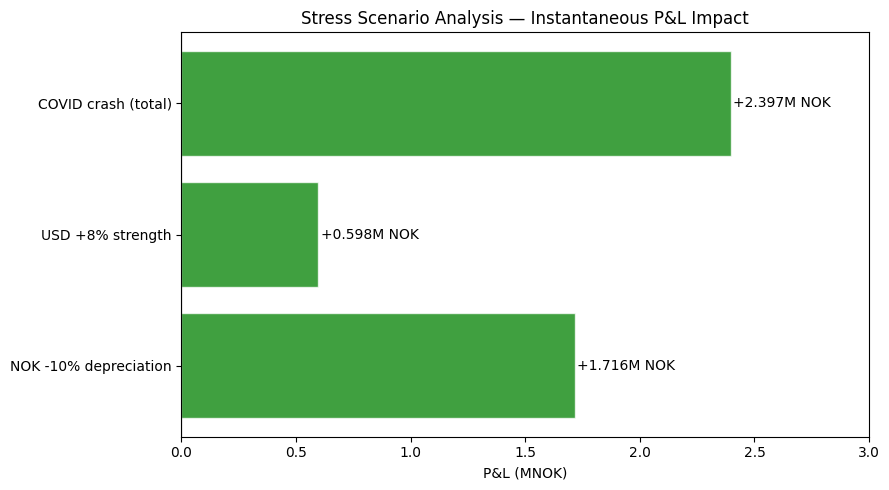

In [3]:
shock_1 = {"EURNOK": 0.10, "USDNOK": 0.10, "GBPNOK": 0.10, "EURUSD": 0.00}

pnl_shock_1 = sum(positions[pair] * np.log(1 + shock) for pair, shock in shock_1.items())

print(f"NOK -10% depreciation: {pnl_shock_1:>15,.0f} NOK")

shock_2 = {"EURNOK": 0.02, "USDNOK": 0.08, "GBPNOK": 0.04, "EURUSD": -0.05}

pnl_shock_2 = sum(positions[pair] * np.log(1 + shock) for pair, shock in shock_2.items())

print(f"USD +8% strength:      {pnl_shock_2:>15,.0f} NOK")

covid_returns = log_returns.loc["2020-02-15":"2020-03-31"]

daily_pnl_covid = sum(covid_returns[pair] * notional for pair, notional in positions.items())

print(f"COVID crash total P&L: {daily_pnl_covid.sum():>15,.0f} NOK")
print(f"Worst single day:      {daily_pnl_covid.min():>15,.0f} NOK")
print(f"Duration:              {len(daily_pnl_covid)} trading days")

scenarios = {
    "NOK -10% depreciation": pnl_shock_1,
    "USD +8% strength": pnl_shock_2,
    "COVID crash (total)": daily_pnl_covid.sum(),
}

fig, ax = plt.subplots(figsize=(9, 5))

colours = ["red" if v < 0 else "green" for v in scenarios.values()]
bars = ax.barh(list(scenarios.keys()), 
               [v / 1_000_000 for v in scenarios.values()], 
               color=colours, alpha=0.75, edgecolor="white")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("P&L (MNOK)")
ax.set_title("Stress Scenario Analysis — Instantaneous P&L Impact")

for bar, val in zip(bars, scenarios.values()):
    ax.text(val / 1_000_000 + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f"{val/1e6:+.3f}M NOK",
            va="center", ha="left" if val >= 0 else "right", fontsize=10)

ax.set_xlim(right=3)
plt.tight_layout()
plt.show()